In [2]:
OUTDIR = "/scratch/users/wx07/spage_out"  # folder containing SpaGE outputs
SUBSET_FILE = "/home/groups/zinaida/warren/SpaGE/cell_barcodes_filtered.txt"  # text file with one barcode per line
OUTPUT_TAG = "roi1"  # used to name the output CSV; change as needed

# %%
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon

import matplotlib.pyplot as plt

In [3]:
out = Path(OUTDIR)

imputed = np.load(out / "imputed_unknown.npy")           # shape: (n_cells, n_unknown_genes)
true    = np.load(out / "X_sp_unknown_true.npy")         # shape: (n_cells, n_unknown_genes)

# Load gene list (unknown) and barcodes
meta = json.load(open(out / "gene_split.json"))
unknown_genes = meta["unknown"]

barcodes = pd.read_csv(out / "cell_barcodes.tsv")["barcode"].astype(str).tolist()

print("Loaded:")
print("  imputed shape:", imputed.shape)
print("  true shape   :", true.shape)
print("  #unknown genes:", len(unknown_genes))
print("  #barcodes     :", len(barcodes))
assert imputed.shape[0] == true.shape[0] == len(barcodes), "Cell count mismatch among arrays/metadata"
assert imputed.shape[1] == true.shape[1] == len(unknown_genes), "Gene count mismatch among arrays/metadata"

Loaded:
  imputed shape: (149014, 300)
  true shape   : (149014, 300)
  #unknown genes: 300
  #barcodes     : 149014


In [4]:
with open(SUBSET_FILE) as f:
    subset_barcodes = [ln.strip() for ln in f if ln.strip()]

subset_set = set(subset_barcodes)
subset_idx = [i for i, b in enumerate(barcodes) if b in subset_set]

print(f"Subset barcodes provided: {len(subset_barcodes)}")
print(f"Matched barcodes in OUTDIR arrays: {len(subset_idx)}")
if not subset_idx:
    raise ValueError("No subset barcodes matched the saved arrays. Check SUBSET_FILE and cell_barcodes.tsv.")

Subset barcodes provided: 86350
Matched barcodes in OUTDIR arrays: 86350


In [5]:
pred_sub = imputed[subset_idx, :]
true_sub = true[subset_idx, :]
print("Subset shapes:")
print("  pred_sub:", pred_sub.shape)
print("  true_sub:", true_sub.shape)

Subset shapes:
  pred_sub: (86350, 300)
  true_sub: (86350, 300)


Saved subset gene-wise metrics to: /scratch/users/wx07/spage_out/gene_metrics__subset_roi1.csv
Summary:
               PCC        RMSE          JS
count  300.000000  300.000000  300.000000
mean     0.154320    1.332381    0.662699
std      0.129511    0.568077    0.137008
min     -0.025832    0.542050    0.177895
25%      0.055165    0.902111    0.612339
50%      0.110620    1.169059    0.706319
75%      0.213701    1.646131    0.758168
max      0.624266    3.446691    0.830121


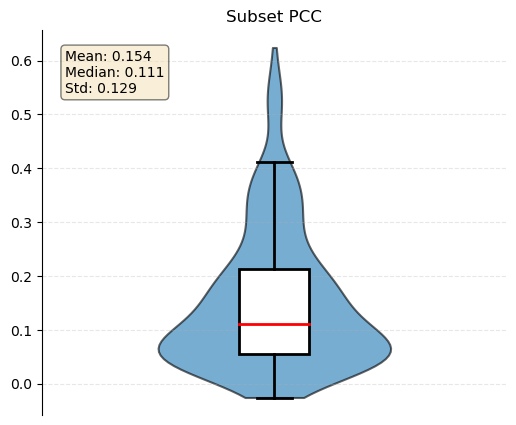

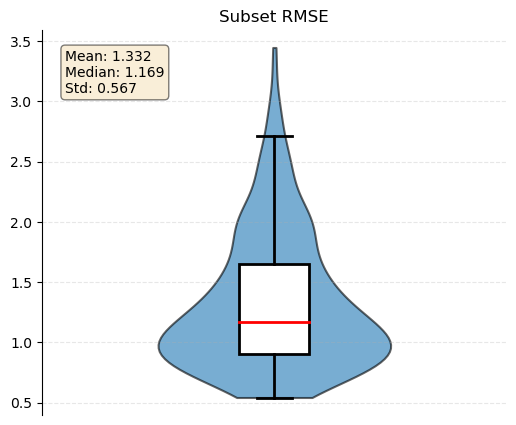

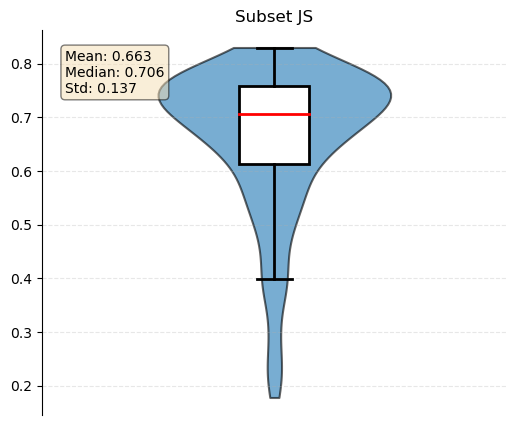

In [6]:
eps = 1e-10
rows = []

for g, gene in enumerate(unknown_genes):
    p = pred_sub[:, g]
    t = true_sub[:, g]

    # Pearson correlation (guard zero variance)
    if np.std(p) == 0 or np.std(t) == 0:
        pcc = float("nan")
    else:
        pcc, _ = pearsonr(p, t)

    # RMSE
    rmse = np.sqrt(np.mean((p - t) ** 2))

    # Jensen–Shannon divergence (treat across-cells distribution for this gene)
    pp = np.abs(p) + eps
    tt = np.abs(t) + eps
    pp = pp / pp.sum()
    tt = tt / tt.sum()
    js = jensenshannon(pp, tt)

    rows.append({"Gene": gene, "PCC": pcc, "RMSE": rmse, "JS": js})

df_subset_metrics = pd.DataFrame(rows)
df_subset_metrics.head()

# %%
# Save metrics
out_csv = out / f"gene_metrics__subset_{OUTPUT_TAG}.csv"
df_subset_metrics.to_csv(out_csv, index=False)
print("Saved subset gene-wise metrics to:", out_csv)
print("Summary:\n", df_subset_metrics[["PCC", "RMSE", "JS"]].describe())

# %%
# Violin + box plots (one figure per metric; matplotlib only; no custom colors)
metrics_to_plot = ["PCC", "RMSE", "JS"]

for metric in metrics_to_plot:
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)

    vals = df_subset_metrics[metric].dropna().values

    parts = ax.violinplot([vals], positions=[0],
                          showmeans=False, showmedians=False, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_alpha(0.6)
        pc.set_edgecolor("black")
        pc.set_linewidth(1.5)

    _bp = ax.boxplot([vals], positions=[0], widths=0.15,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor="white", edgecolor="black", linewidth=2),
                     whiskerprops=dict(color="black", linewidth=2),
                     capprops=dict(color="black", linewidth=2),
                     medianprops=dict(color="red", linewidth=2.0))

    ax.set_title(f"Subset {metric}")
    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    mean_val = np.nanmean(vals)
    median_val = np.nanmedian(vals)
    std_val = np.nanstd(vals)
    ax.text(0.05, 0.95, f"Mean: {mean_val:.3f}\nMedian: {median_val:.3f}\nStd: {std_val:.3f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    plt.show()

In [7]:
# --- replace your plotting block with this ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def safe_violin_box_two_groups(values_a, values_b, title, labels=("Model","Baseline")):
    """Side-by-side violin+box that safely handles all-NaN / empty arrays."""
    A = pd.to_numeric(pd.Series(values_a), errors="coerce")
    B = pd.to_numeric(pd.Series(values_b), errors="coerce")
    A = A[np.isfinite(A)].values
    B = B[np.isfinite(B)].values

    # If either side is empty, draw a friendly message instead of crashing
    if len(A) == 0 or len(B) == 0:
        fig = plt.figure(figsize=(7, 3.5))
        ax = fig.add_subplot(111)
        ax.axis("off")
        ax.set_title(title)
        ax.text(
            0.5, 0.5,
            f"No finite values to plot.\n{labels[0]} count: {len(A)} | {labels[1]} count: {len(B)}\n"
            "This often happens when PCC is undefined (zero variance in subset). "
            "Try plotting RMSE/JS or increase subset size.",
            ha="center", va="center", fontsize=10
        )
        plt.show()
        return

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111)

    parts = ax.violinplot([A, B], positions=[0, 1],
                          showmeans=False, showmedians=False, showextrema=False)
    _bp = ax.boxplot([A, B], positions=[0, 1], widths=0.25, patch_artist=True, showfliers=False)

    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(list(labels))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    def stats_txt(vals):
        return f"Mean: {np.nanmean(vals):.3f}\nMedian: {np.nanmedian(vals):.3f}\nStd: {np.nanstd(vals):.3f}"

    ax.text(0.02, 0.97, f"{labels[0]}\n{stats_txt(A)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=9, bbox=dict(boxstyle="round", alpha=0.3))
    ax.text(0.72, 0.97, f"{labels[1]}\n{stats_txt(B)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=9, bbox=dict(boxstyle="round", alpha=0.3))

    plt.show()

# Now call the safe function instead of the previous one:
safe_violin_box_two_groups(df_model["PCC"],  df_base["PCC"],  f"Subset PCC — {OUTPUT_TAG}")
safe_violin_box_two_groups(df_model["RMSE"], df_base["RMSE"], f"Subset RMSE — {OUTPUT_TAG}")
safe_violin_box_two_groups(df_model["JS"],   df_base["JS"],   f"Subset JS — {OUTPUT_TAG}")


NameError: name 'df_model' is not defined

Loaded:
  imputed: (149014, 300)  true: (149014, 300)
  #unknown_genes: 300  #barcodes: 149014
Subset barcodes provided: 86350 | matched in arrays: 86350
Subset shapes -> pred_sub: (86350, 300)  true_sub: (86350, 300)


/home/groups/zinaida/warren/miniconda3/envs/spage_env/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4427: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))



MODEL subset summary:
               PCC        RMSE          JS
count  300.000000  300.000000  300.000000
mean     0.154320    1.332381    0.662699
std      0.129511    0.568077    0.137008
min     -0.025832    0.542050    0.177895
25%      0.055165    0.902111    0.612339
50%      0.110620    1.169059    0.706319
75%      0.213701    1.646131    0.758168
max      0.624266    3.446691    0.830121

BASELINE subset summary:
        PCC        RMSE          JS
count  0.0  300.000000  300.000000
mean   NaN    1.168526    0.673131
std    NaN    0.448411    0.127560
min    NaN    0.439954    0.151106
25%    NaN    0.823829    0.637898
50%    NaN    1.036511    0.722430
75%    NaN    1.414706    0.755400
max    NaN    2.532382    0.804093
Wrote: /scratch/users/wx07/spage_out/gene_metrics__subset_no_NK_fibro_endo__model.csv
Wrote: /scratch/users/wx07/spage_out/gene_metrics__subset_no_NK_fibro_endo__baseline.csv
Wrote: /scratch/users/wx07/spage_out/gene_metrics__subset_no_NK_fibro_endo__compa

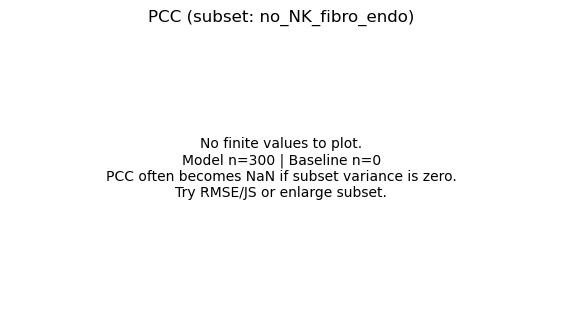

RMSE: finite counts — Model: 300 | Baseline: 300 | Total genes: 300


AttributeError: 'Spine' object has no attribute 'setVisible'

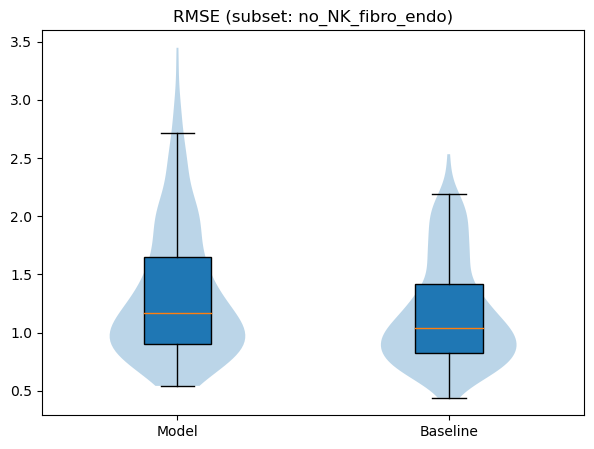

In [8]:
OUTPUT_TAG = "no_NK_fibro_endo"                           # used in output filenames
SAVE_PNG = True                                           # set False to only show plots

# %%
import json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

out = Path(OUTDIR)

# --- Load arrays/metadata produced by the SpaGE main script ---
imputed = np.load(out / "imputed_unknown.npy")         # (n_cells, n_genes_unknown)
true    = np.load(out / "X_sp_unknown_true.npy")       # (n_cells, n_genes_unknown)
meta    = json.load(open(out / "gene_split.json"))
unknown_genes = meta["unknown"]
barcodes = pd.read_csv(out / "cell_barcodes.tsv")["barcode"].astype(str).tolist()

print("Loaded:")
print("  imputed:", imputed.shape, " true:", true.shape)
print("  #unknown_genes:", len(unknown_genes), " #barcodes:", len(barcodes))
assert imputed.shape[0] == true.shape[0] == len(barcodes)
assert imputed.shape[1] == true.shape[1] == len(unknown_genes)

# --- Read subset barcodes (already filtered on the R side) ---
with open(SUBSET_FILE) as f:
    subset_barcodes = [ln.strip() for ln in f if ln.strip()]
subset_set = set(subset_barcodes)
subset_idx = [i for i, b in enumerate(barcodes) if b in subset_set]
print(f"Subset barcodes provided: {len(subset_barcodes)} | matched in arrays: {len(subset_idx)}")
if not subset_idx:
    raise ValueError("No subset barcodes matched. Check SUBSET_FILE vs OUTDIR/cell_barcodes.tsv")

# --- Subset arrays to those cells ---
pred_sub = imputed[subset_idx, :]
true_sub = true[subset_idx, :]
print("Subset shapes -> pred_sub:", pred_sub.shape, " true_sub:", true_sub.shape)

# %%
# === Compute gene-wise metrics for MODEL and BASELINE on the subset ===
eps = 1e-10

def gene_metrics_for_arrays(pred_2d, true_2d, genes):
    """pred_2d/true_2d: (n_cells_subset, n_genes) -> DataFrame with PCC/RMSE/JS per gene"""
    rows = []
    for g, gene in enumerate(genes):
        p = pred_2d[:, g]
        t = true_2d[:, g]
        if np.std(p) == 0 or np.std(t) == 0:
            pcc = float("nan")
        else:
            pcc, _ = pearsonr(p, t)
        rmse = np.sqrt(np.mean((p - t) ** 2))
        pp = np.abs(p) + eps; tt = np.abs(t) + eps
        pp = pp / pp.sum(); tt = tt / tt.sum()
        js = jensenshannon(pp, tt)
        rows.append({"Gene": gene, "PCC": pcc, "RMSE": rmse, "JS": js})
    return pd.DataFrame(rows)

# MODEL metrics on subset
df_model = gene_metrics_for_arrays(pred_2d=pred_sub, true_2d=true_sub, genes=unknown_genes)

# BASELINE = per-gene mean across ALL cells, then evaluate on the subset
gene_means_all = true.mean(axis=0)  # (n_genes,)
baseline_sub   = np.tile(gene_means_all, (len(subset_idx), 1))
df_base  = gene_metrics_for_arrays(pred_2d=baseline_sub, true_2d=true_sub, genes=unknown_genes)

print("\nMODEL subset summary:\n", df_model[["PCC","RMSE","JS"]].describe())
print("\nBASELINE subset summary:\n", df_base[["PCC","RMSE","JS"]].describe())

# --- Save CSVs + merged comparison with deltas ---
csv_model = out / f"gene_metrics__subset_{OUTPUT_TAG}__model.csv"
csv_base  = out / f"gene_metrics__subset_{OUTPUT_TAG}__baseline.csv"
df_model.to_csv(csv_model, index=False); df_base.to_csv(csv_base, index=False)
print("Wrote:", csv_model); print("Wrote:", csv_base)

df_cmp = (df_model.rename(columns={"PCC":"PCC_model","RMSE":"RMSE_model","JS":"JS_model"})
                 .merge(df_base.rename(columns={"PCC":"PCC_base","RMSE":"RMSE_base","JS":"JS_base"}),
                        on="Gene", how="inner"))
df_cmp["ΔPCC"]  = df_cmp["PCC_model"]  - df_cmp["PCC_base"]
df_cmp["ΔRMSE"] = df_cmp["RMSE_base"] - df_cmp["RMSE_model"]   # positive => model better
df_cmp["ΔJS"]   = df_cmp["JS_base"]   - df_cmp["JS_model"]     # positive => model better
csv_cmp = out / f"gene_metrics__subset_{OUTPUT_TAG}__compare.csv"
df_cmp.to_csv(csv_cmp, index=False)
print("Wrote:", csv_cmp)

# %%
# === Safe plotting helpers ===
def finite_vals(series_like):
    arr = pd.to_numeric(pd.Series(series_like), errors="coerce")
    arr = arr[np.isfinite(arr)]
    return arr.values

def safe_violin_box_two_groups(values_a, values_b, title, labels=("Model","Baseline"), savepath=None):
    """Side-by-side violin+box; handles all-NaN/empty gracefully."""
    A = finite_vals(values_a); B = finite_vals(values_b)

    if len(A) == 0 or len(B) == 0:
        fig = plt.figure(figsize=(7, 3.6)); ax = fig.add_subplot(111)
        ax.axis("off"); ax.set_title(title)
        ax.text(
            0.5, 0.5,
            f"No finite values to plot.\n{labels[0]} n={len(A)} | {labels[1]} n={len(B)}\n"
            "PCC often becomes NaN if subset variance is zero.\nTry RMSE/JS or enlarge subset.",
            ha="center", va="center", fontsize=10
        )
        if savepath and SAVE_PNG:
            fig.savefig(savepath, dpi=200, bbox_inches="tight")
        plt.show()
        return

    fig = plt.figure(figsize=(7, 5)); ax = fig.add_subplot(111)

    parts = ax.violinplot([A, B], positions=[0, 1],
                          showmeans=False, showmedians=False, showextrema=False)
    _bp = ax.boxplot([A, B], positions=[0, 1], widths=0.25, patch_artist=True, showfliers=False)

    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(list(labels))
    ax.spines["top"].setVisible(False); ax.spines["right"].setVisible(False); ax.spines["bottom"].setVisible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    def stats_txt(vals):
        return f"Mean: {np.nanmean(vals):.3f}\nMedian: {np.nanmedian(vals):.3f}\nStd: {np.nanstd(vals):.3f}"
    ax.text(0.02, 0.97, f"{labels[0]}\n{stats_txt(A)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=9, bbox=dict(boxstyle="round", alpha=0.25))
    ax.text(0.70, 0.97, f"{labels[1]}\n{stats_txt(B)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=9, bbox=dict(boxstyle="round", alpha=0.25))

    if savepath and SAVE_PNG:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

def report_finite_counts(df_model, df_base, metric):
    m = np.isfinite(df_model[metric]).sum()
    b = np.isfinite(df_base [metric]).sum()
    print(f"{metric}: finite counts — Model: {m} | Baseline: {b} | Total genes: {len(df_model)}")

# %%
# === Plot: Model vs Baseline on the subset (PCC / RMSE / JS) ===
for metric in ["PCC", "RMSE", "JS"]:
    report_finite_counts(df_model, df_base, metric)
    safe_violin_box_two_groups(
        df_model[metric], df_base[metric],
        title=f"{metric} (subset: {OUTPUT_TAG})",
        savepath=out / f"subset_{OUTPUT_TAG}_{metric}_model_vs_baseline.png"
    )

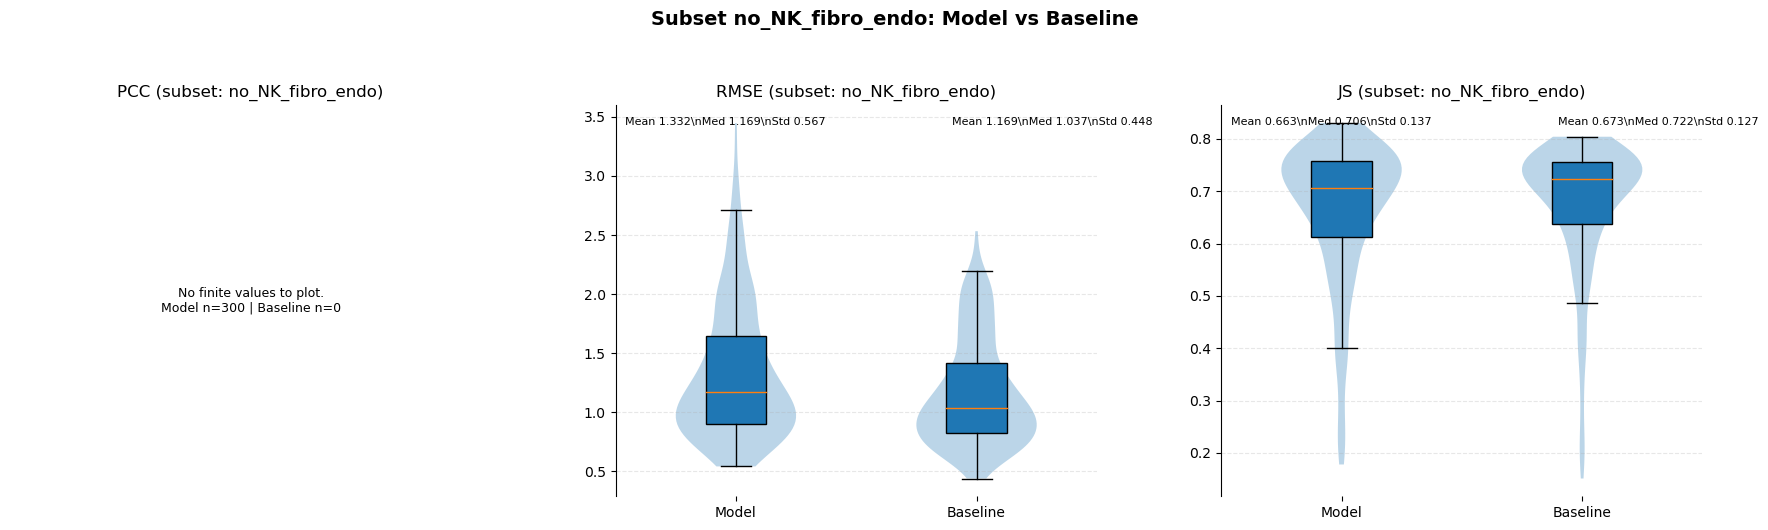

In [21]:
# --- Compact side-by-side violin+box plots for PCC, RMSE, JS ---
def finite_vals(series_like):
    arr = pd.to_numeric(pd.Series(series_like), errors="coerce")
    arr = arr[np.isfinite(arr)]
    return arr.values

def safe_violin_box_two_groups(values_a, values_b, title, labels=("Model","Baseline"), ax=None):
    """Draw one violin+box safely into a provided Axes."""
    A = finite_vals(values_a)
    B = finite_vals(values_b)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if len(A) == 0 or len(B) == 0:
        ax.axis("off")
        ax.set_title(title)
        ax.text(0.5, 0.5,
                f"No finite values to plot.\n{labels[0]} n={len(A)} | {labels[1]} n={len(B)}",
                ha="center", va="center", fontsize=9)
        return

    ax.violinplot([A, B], positions=[0, 1], showmeans=False, showmedians=False, showextrema=False)
    ax.boxplot([A, B], positions=[0, 1], widths=0.25,
               patch_artist=True, showfliers=False)

    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(list(labels))
    for spine in ["top", "right", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    def stats_txt(vals):
        return f"Mean {np.nanmean(vals):.3f}\\nMed {np.nanmedian(vals):.3f}\\nStd {np.nanstd(vals):.3f}"
    ax.text(0.02, 0.97, stats_txt(A), transform=ax.transAxes, va="top", fontsize=8)
    ax.text(0.70, 0.97, stats_txt(B), transform=ax.transAxes, va="top", fontsize=8)

# --- Combined figure with 3 subplots in a single row ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["PCC", "RMSE", "JS"]

for ax, metric in zip(axes, metrics):
    safe_violin_box_two_groups(
        df_model[metric], df_base[metric],
        title=f"{metric} (subset: {OUTPUT_TAG})",
        ax=ax
    )

fig.suptitle(f"Subset {OUTPUT_TAG}: Model vs Baseline", fontsize=14, fontweight="bold", y=1.05)
fig.tight_layout()
plt.show()


In [9]:
# --- Compute baseline from the reference (ref-based mean expression) ---
X_ref_unknown = np.load(out / "X_ref_unknown.npy")  # already saved by SpaGE script
gene_means_ref = X_ref_unknown.mean(axis=0)         # per-gene mean across reference cells

rows_base_ref = []
for g, gene in enumerate(unknown_genes):
    baseline_pred_ref = np.full(len(subset_idx), gene_means_ref[g], dtype=float)
    t = true_sub[:, g]

    if np.std(baseline_pred_ref) == 0 or np.std(t) == 0:
        pcc_r = float("nan")
    else:
        pcc_r, _ = pearsonr(baseline_pred_ref, t)
    rmse_r = np.sqrt(np.mean((baseline_pred_ref - t)**2))
    bp = np.abs(baseline_pred_ref) + 1e-10
    tt = np.abs(t) + 1e-10
    bp = bp / bp.sum(); tt = tt / tt.sum()
    js_r = jensenshannon(bp, tt)
    rows_base_ref.append({"Gene": gene, "PCC": pcc_r, "RMSE": rmse_r, "JS": js_r})

df_base_ref = pd.DataFrame(rows_base_ref)
df_base_ref.to_csv(out / f"gene_metrics__subset_{OUTPUT_TAG}__baseline_ref.csv", index=False)
print("✓ Baseline (reference) metrics saved:", out / f"gene_metrics__subset_{OUTPUT_TAG}__baseline_ref.csv")


✓ Baseline (reference) metrics saved: /scratch/users/wx07/spage_out/gene_metrics__subset_no_NK_fibro_endo__baseline_ref.csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _finite_vals(x):
    arr = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy()
    return arr[np.isfinite(arr)]

def safe_violin_box_three_groups(values_a, values_b, values_c, title,
                                 labels=("Model","Query-mean","Ref-mean"),
                                 ax=None):
    """Three-group violin+box with guards for empty/degenerate inputs."""
    A, B, C = map(_finite_vals, (values_a, values_b, values_c))
    arrays  = [A, B, C]
    labs    = list(labels)
    idxs    = list(range(3))

    # Keep only non-empty groups
    kept = [(i, lab, arr) for i, lab, arr in zip(idxs, labs, arrays) if len(arr) > 0]

    # Nothing to plot
    if not kept:
        if ax is None:
            fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.axis("off")
        ax.set_title(title)
        ax.text(0.5, 0.5, "No finite values to plot for any group.",
                ha="center", va="center", fontsize=10)
        plt.show()
        return

    if ax is None:
        # width ~ 6 per panel
        fig, ax = plt.subplots(figsize=(max(6, 3*len(kept)), 5))

    # Positions for the kept groups: 0,1,2 (skipping the empty ones)
    positions = np.arange(len(kept))

    # --- VIOLINS: only for arrays with >=2 points AND non-zero spread
    v_data = []
    v_pos  = []
    for j, (i, lab, arr) in enumerate(kept):
        if len(arr) >= 2 and np.ptp(arr) > 0:  # ptp = max - min
            v_data.append(arr)
            v_pos.append(j)

    if len(v_data) > 0:
        ax.violinplot(v_data, positions=v_pos,
                      showmeans=False, showmedians=False, showextrema=False)

    # --- BOXPLOTS: for ALL kept groups (boxplot is OK with 1+ points)
    bp_data = [arr for (_, _, arr) in kept]
    ax.boxplot(bp_data, positions=positions, widths=0.25,
               patch_artist=True, showfliers=False)

    # Cosmetics
    ax.set_title(title)
    ax.set_xticks(positions)
    ax.set_xticklabels([lab for (_, lab, _) in kept])
    for spine in ("top", "right", "bottom"):
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    # Stats text and “missing” notes
    for j, (i, lab, arr) in enumerate(kept):
        mean_val = np.nanmean(arr)
        med_val  = np.nanmedian(arr)
        std_val  = np.nanstd(arr)
        ax.text(j-0.32, 0.97,
                f"n={len(arr)}\nMean {mean_val:.3f}\nMed {med_val:.3f}\nStd {std_val:.3f}",
                transform=ax.transAxes, va="top", fontsize=8)
    # If some groups were empty, mention them
    missing = [lab for (i, lab, arr) in zip(idxs, labs, arrays) if len(arr) == 0]
    if missing:
        ax.text(0.5, -0.12, f"Missing groups (no finite values): {', '.join(missing)}",
                transform=ax.transAxes, ha="center", va="top", fontsize=9)

    plt.tight_layout()


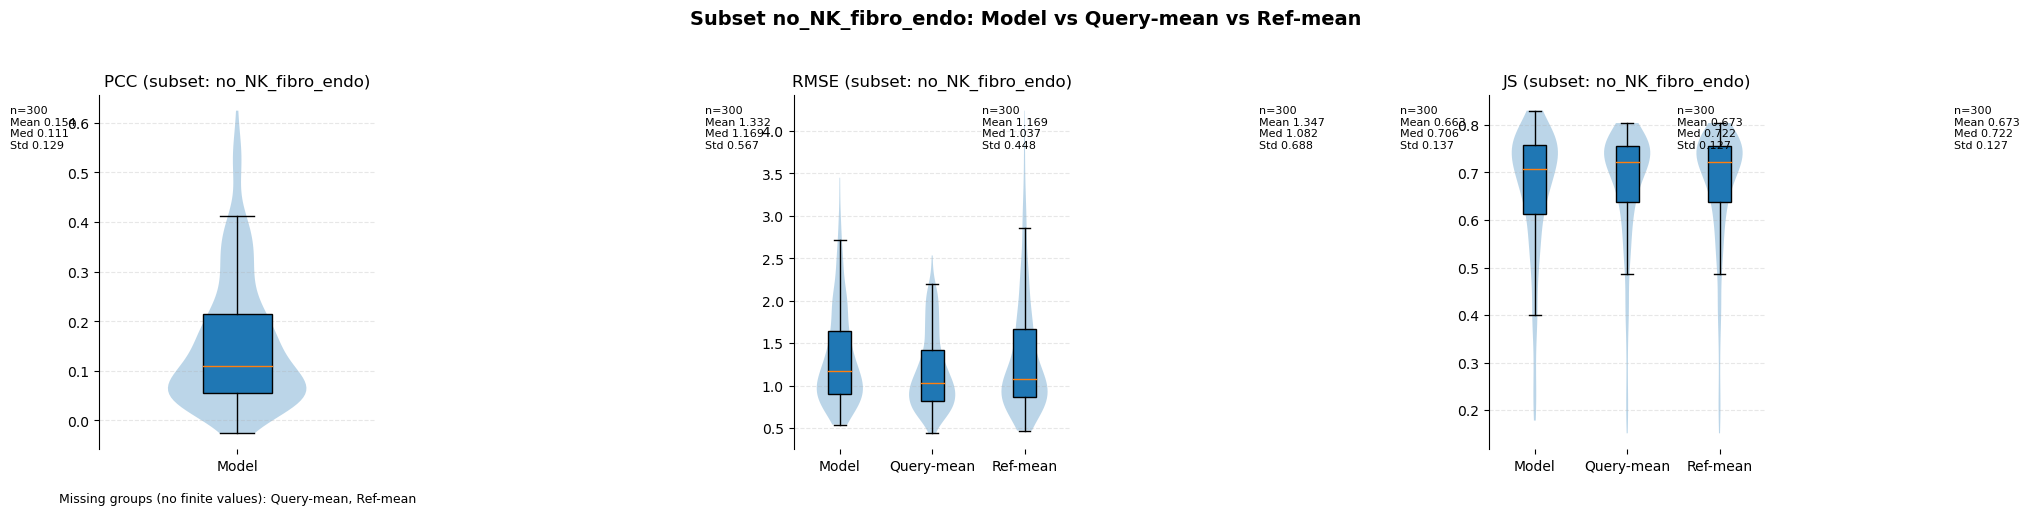

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, metric in zip(axes, ["PCC", "RMSE", "JS"]):
    safe_violin_box_three_groups(
        df_model[metric],
        df_base[metric],       # query-mean baseline
        df_base_ref[metric],   # ref-mean baseline
        title=f"{metric} (subset: {OUTPUT_TAG})",
        ax=ax
    )
fig.suptitle(f"Subset {OUTPUT_TAG}: Model vs Query-mean vs Ref-mean", fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()
